## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd
from TNB_tools.spectra import rotary_power_spectra
import gsw


In [2]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
# # MAC
# vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# DELL
vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")


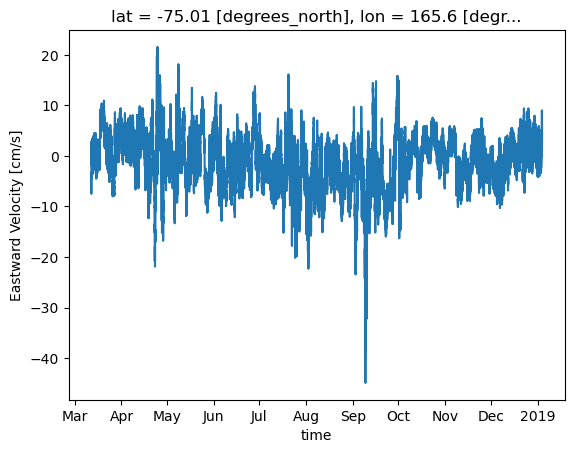

In [5]:
vel.u.plot()

In [6]:
f = gsw.f(-75)
# intertial frequency [cpd]
f_inertial = np.abs(f) * 86400 / (2*np.pi)

In [7]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 1024

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [8]:
# Chi - squared CI workflow 
freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

Text(0.38, 1.02, 'K1')

C:\Users\mblan\AppData\Local\Temp\ipykernel_32976\3991634988.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


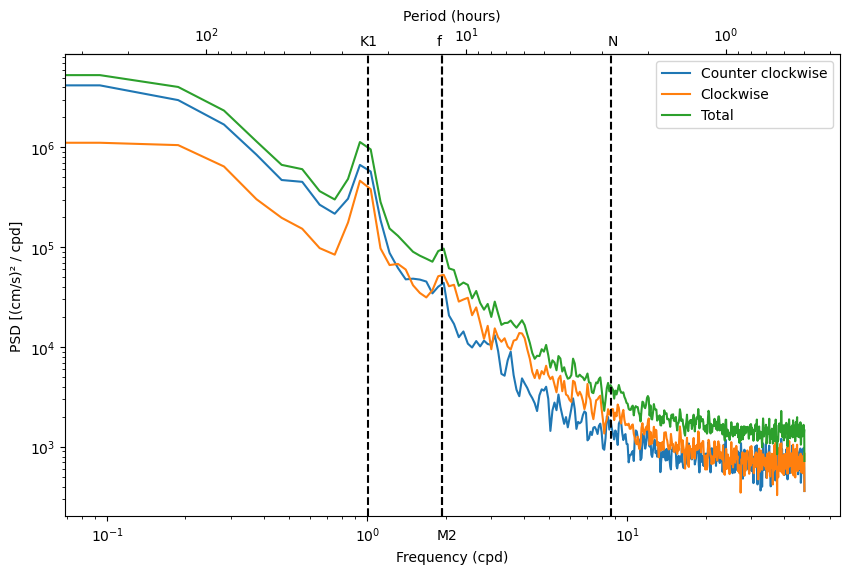

In [9]:
fig = plt.figure(figsize=(10,6))
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k',label='M2',ls='--')
plt.axvline(1.0027, color='k',label='K1',ls='--')
plt.axvline(1e-4*86400, color='k',label='N',ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

Text(0.38, 1.02, 'K1')

C:\Users\mblan\AppData\Local\Temp\ipykernel_32976\2558768422.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


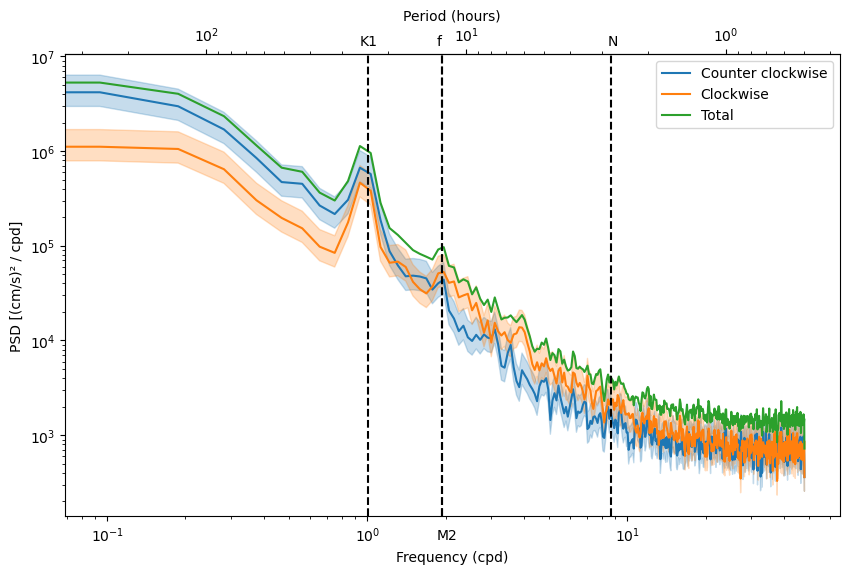

In [10]:
# compute spectra + CI first
# freq, Suu, Svv, Cuv = auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)

# dof, L = dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = spectra_chi2_ci(S_cw, dof)

fig = plt.figure(figsize=(10,6))

freq_cpd = freq * 86400  # compute once, reuse for lines + shading

l1, = plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.fill_between(freq_cpd, S_ccw_lo, S_ccw_hi, color=l1.get_color(), alpha=0.25)

l2, = plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.fill_between(freq_cpd, S_cw_lo, S_cw_hi, color=l2.get_color(), alpha=0.25)

plt.loglog(freq_cpd, (S_ccw + S_cw), label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k', label='M2', ls='--')
plt.axvline(1.0027, color='k', label='K1', ls='--')
plt.axvline(1e-4*86400, color='k', label='N', ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

In [11]:
S_total = S_ccw + S_cw

C:\Users\mblan\AppData\Local\Temp\ipykernel_32976\2972738259.py:17: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


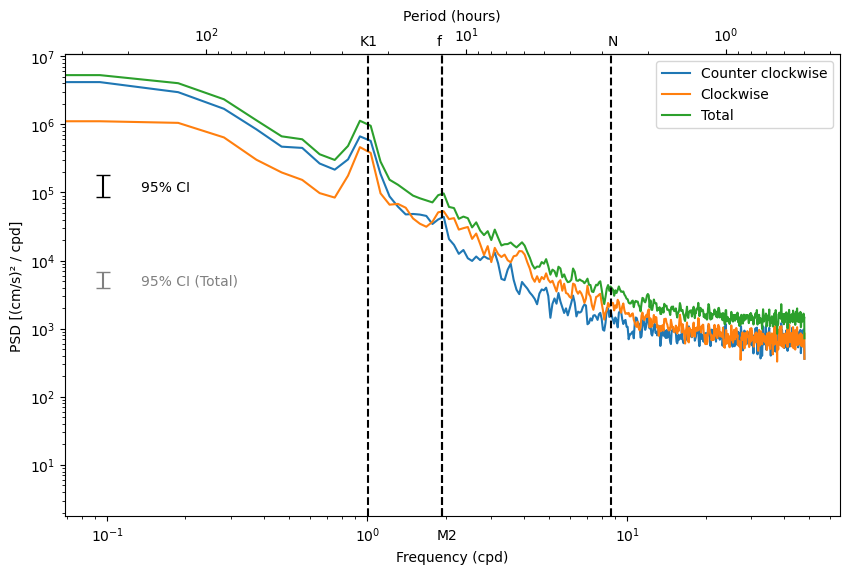

In [12]:
fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

In [13]:
# calculate rotary coefficient and ellipse orientation 
Cr = rotary_power_spectra.rotary_coefficient(S_ccw,S_cw)

In [14]:
sigma = np.arange(10e-2, 10e1, 0.01)
Cr_theory = rotary_power_spectra.rotary_coefficient_theory(sigma,f_inertial)

In [15]:
theta = rotary_power_spectra.ellipse_orientation(Suu,Svv,Cuv)

Text(0.5, 0, 'Freqeuncy [cpd]')

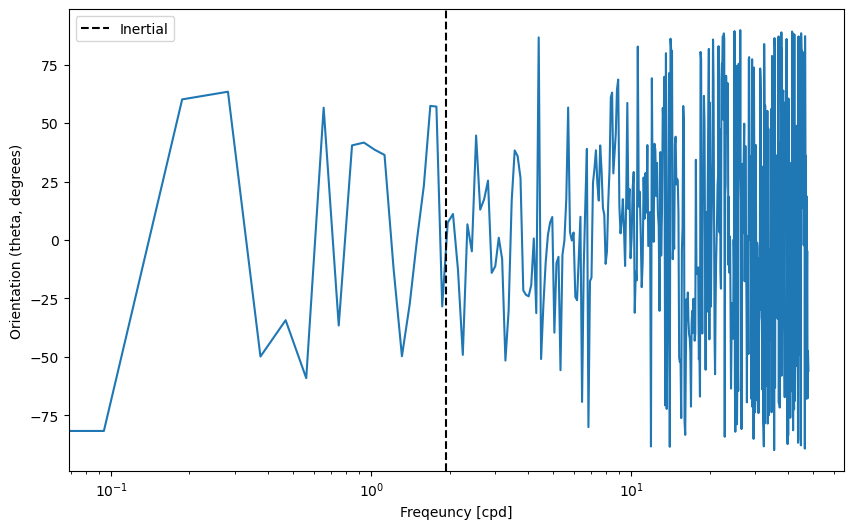

In [16]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, theta)

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Orientation (theta, degrees)')
plt.xlabel('Freqeuncy [cpd]')

Text(0.5, 0, 'Freqeuncy [cpd]')

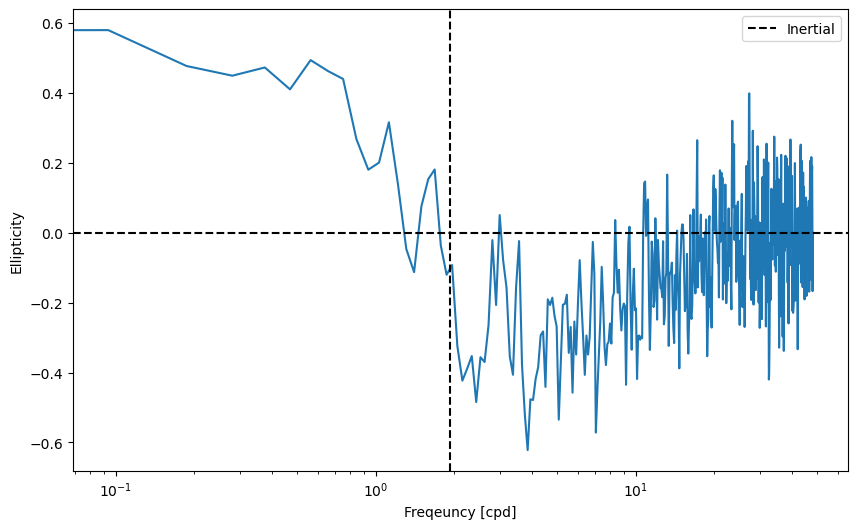

In [17]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, Cr)

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axhline(0, color='k', ls='--')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Ellipticity')
plt.xlabel('Freqeuncy [cpd]')

### Seasonal Spectra 

In [18]:
vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 229kB -4.526 -5.742 -5.113 ... 2.505 2.659 2.424
    v        (time) float64 229kB -3.446 -3.144 -1.277 ... -0.673 -0.9496 -2.092
    w        (time) float64 229kB ...
    pres     (time) float64 229kB ...
    speed    (time) float64 229kB ...
    dir      (time) float64 229kB ...

In [22]:
from TNB_tools.spectra import rotary_spectra_by_period

In [23]:
rotary_spectra_by_period.seasonal_rotary_spectra(ds=vel)

{'autumn': None, 'winter': None, 'spring': None, 'summer': None}

In [50]:
vel.sel(time=slice('2018-06','2018-08'))

<xarray.Dataset> Size: 495kB
Dimensions:  (time: 8832)
Coordinates:
  * time     (time) datetime64[ns] 71kB 2018-06-01 ... 2018-08-31T23:45:00
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 71kB 0.3004 -0.7466 -2.878 ... 1.624 2.119 1.498
    v        (time) float64 71kB -0.412 -2.438 -2.244 ... 15.21 13.54 13.16
    w        (time) float64 71kB ...
    pres     (time) float64 71kB ...
    speed    (time) float64 71kB ...
    dir      (time) float64 71kB ...

In [95]:
subset = vel.sel(time=slice('2018-09-01','2018-09-30'))

In [96]:
len(subset.u)

2880

In [97]:
nperseg = len(subset.u)/2

In [98]:
nperseg

1440.0

In [99]:
# Chi - squared CI workflow 
freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(subset.u, subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

In [100]:
S_total = S_ccw + S_cw

In [101]:
%matplotlib widget

C:\Users\mblan\AppData\Local\Temp\ipykernel_32976\2972738259.py:17: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


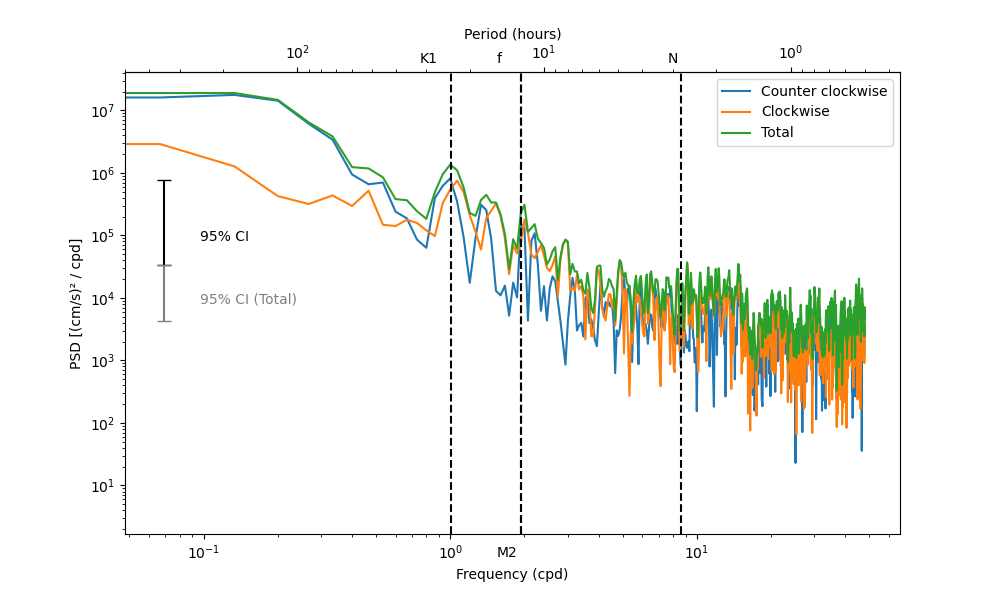

In [102]:
fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')